<a href="https://colab.research.google.com/github/d-toups/workout-data-analysis/blob/main/Dennis_Toups_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello, my name is Dennis Toups and welcome to my final course project for CSCI 4730 Data Analysis. For my project, I chose to analyze a Kaggle dataset that captured exercise metrics for gym attendees. The dataset is large with a variety of data to be analyzed. I chose to focus on age, gender, workout type, workout duration, and calories burned metrics. Workout type falls into five categories: cardio, strength training, high-intensity interval training (HIIT), yoga, and crossfit.

To begin, the code below begins the program by bringing in necessary packages and loading the dataset from .csv to dataframe (the columns specified refer to the desired attributes mentioned above).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

################### Function Definition #######################################

""" Load Dataset ***********************************************************
Purpose: Reads .csv dataset into pandas dataframe

Inputs: filepath - file to be read in

Outputs: df - dataset in dataframe format

----------------------------------------------------------------------------"""

def load_dataset(filepath):
    # Use specified columns to read in Age, Gender, Workout Type, Workout
    # Duration, and Calories Burned
    df = pd.read_csv(filepath, usecols=[2, 3, 5, 6, 7])
    return df

The next step is to clean the dataset. The function below takes the dataframe in, checks for and drops null values, streamlines string case, and adds features and further cleans the data.

In [ ]:
""" Clean Dataset *************************************************************
Purpose: Clean raw dataset, create Calories Per Minute feature

Inputs: df - dataset consisting workout metrics

Outputs: df - cleaned dataset to be analyzed
        df_male - cleaned dataset to be analyzed consisting of male data
        df_female - cleaned dataset to be analyzed consisting of female data
        df_adults - cleaned dataset consisting of both genders together in one
        dataframe. Needed for one of the visualizations generated by
        create_visualizations.

----------------------------------------------------------------------------"""

def clean_dataset(df):
    # Check for and remove missing values
    print('\nCheck null values:\n', df.isna().sum())
    df.dropna()

    # Clean strings to title format
    df.columns = df.columns.str.title()
    df.columns = df.columns.str.replace("_", ' ')
    df['Gender'] = df.Gender.str.title()

    # We want to keep the HIIT elements uppercase, all others title case
    df['Workout Type'].apply( lambda x: x.upper() if x.isupper() else \
                             x.title())

    # Add calories per minute feature
    df['Calories Per Minute'] = df['Calories Burned'] / df[\
                                                    'Workout Duration Minutes']
    # Filter out 'Other' values for gender
    df = df[df['Gender'] != 'Other']

    # Bin ages into age groups
    age_bins = [17, 34, 64, 200]
    age_groups = ['Young Adult', 'Adult', 'Senior']
    df['Age Group'] = pd.cut(df['Age'], bins = age_bins, labels=age_groups)

    # Categorize Workout Type for later analysis
    df['Quantified Workout Type'] = df['Workout Type'].astype('category')

    # Separate by gender, retain only 'Male' and 'Female' data
    df_male = df[df['Gender'] == 'Male']
    print('\nMale samples\n', df_male['Gender'].count())
    df_female = df[df['Gender'] == 'Female']
    print('\nFemale samples\n', df_female['Gender'].count())

    # Check for consistency in categorical features
    print('\nGender values: ', df_male['Gender'].unique(), df_female[\
                                                            'Gender'].unique())
    print('\nWorkout Type values: ', df['Workout Type'].unique())
    df_adults = df[df['Age Group'] != 'Seniors']
    return df, df_male, df_female, df_adults

Specific cleaning actions taken are:
- keep "HIIT" capitalized by using a lambda function
- add Calories Per Minute to aid further analysis
- filter out ambiguous "Other" entries for gender
- bins ages into age groups for cohort analysis
- categorize Workout Type
- Confirm data cleaning by checking unique values of gender and workout type

Next, we explore the dataset. We first generate basic statistical information by showing sample count, sample counts by gender, quantile boxplots and printed statistics as well as plot densities by gender and age group for each feature.

In [ ]:
""" Explore Dataset ***********************************************************
Purpose: Generate statistics from the dataset as well as box and density plots
        to begin identifying trends.

Inputs: df - dataset consisting of one gender's exercise metrics
        gender - the gender currently being analyzed
Outputs: Initial visualizations of the dataset.

----------------------------------------------------------------------------"""

def explore_dataset(df, gender):

    # Print summary information
    print('\nSamples By Age:\n', df['Age Group'].value_counts())

    # Display summary statistics for all columns
    pd.set_option('display.max_columns', None)
    print('\nSummary Statistics\n', df.describe())
    pd.reset_option('display.max_columns')

    # View age group statistics:
    cols = ['Workout Duration Minutes', 'Calories Burned', \
            'Calories Per Minute']

    for col in cols:

        # Quartile boxplots
        ax = df.boxplot(column=col, by = 'Age Group')
        ax.get_figure().suptitle('')
        plt.title(f'{gender} {col} Quartiles')
        plt.ylabel(f'{col}')
        plt.figure()
        ax.plot

        # Plot densities
        print(f'\n{gender} {col} Age Group Statistics:\n', \
              df.groupby('Age Group', observed=True)[col].agg(['mean', 'std',\
                                                                'var']) )
        ax = df.groupby('Age Group', observed=True)[col].plot(\
                kind='density', title=f'{gender} {col} Density', legend=True)
        plt.xlabel(f'{col}')
        plt.figure()
        ax.plot

    # Print statistics for workout type preferences (visualized in
    # create_visualizations function)
    print(f'\n{gender} Workout Type Statistics:\n', df.groupby('Age Group')\
          ['Workout Type'].value_counts())

    return

Below are a sample of some of the plots generated. I have only included those for Calories Per Minute as they are most pertinent to further analysis.

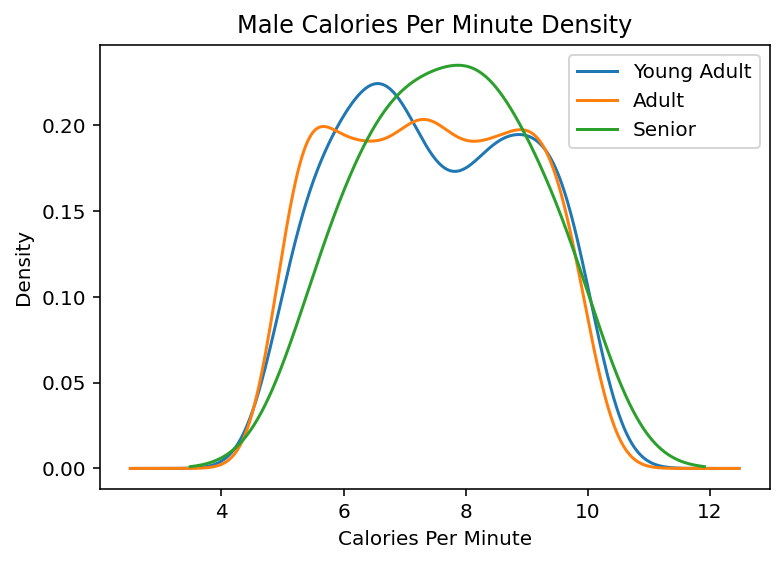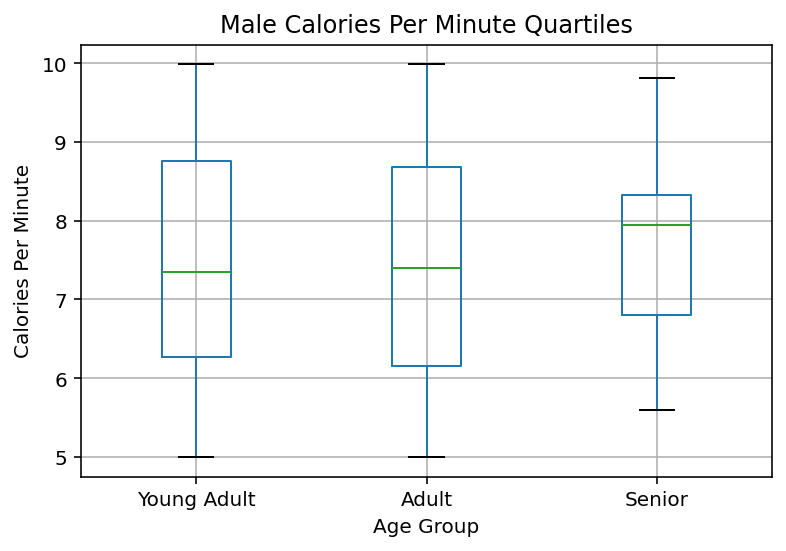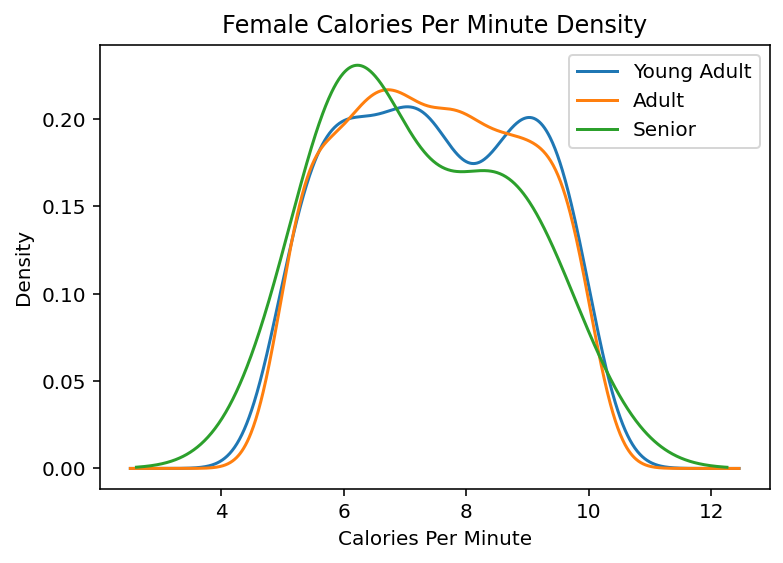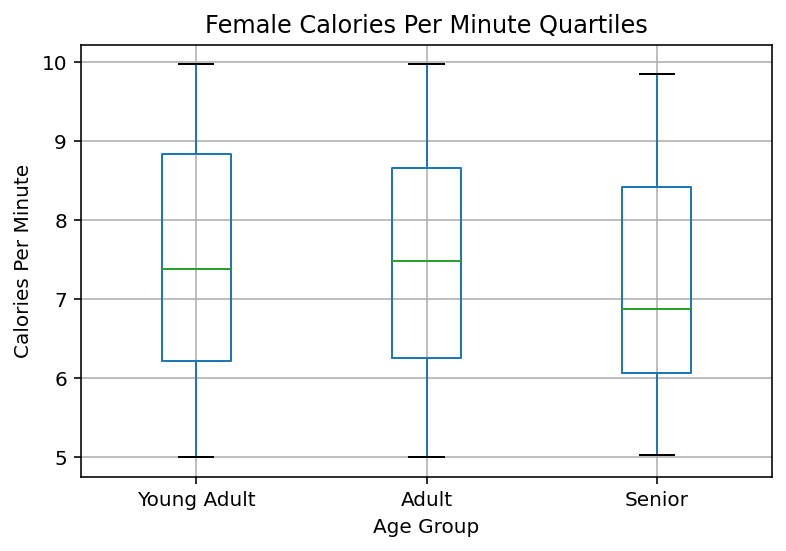

Next, we create more visualizations to further identify trends. I chose to show a bar graph for the percentage each workout type consisted of for each gender and age group, ie, which workouts do these groups refer, if any. I also generated stacked density plots of Calories Per Minute, similar to the above but here further categorized by age group and workout type. I was specifically curious to observe whether high-intensity workouts such as HIIT and crossfit map to higher calories per minute metrics.

In [ ]:
""" Create Visualizations *****************************************************
Purpose: Generate visualizations to illustrate insights from the dataset.

Inputs: df - dataframe assumed to be specific to gender
        gender - which gender is currently being analyzed (needed for plotting)
        df_a - dataframe consisting of both genders in the same dataframe

Outputs: Generates bar graphs showing workout type preferences as well as
        stacked density plots for calories burned per minute by age group and
        by workout type.

----------------------------------------------------------------------------"""

def create_visualizations(df, gender, df_a):
    # Normalize value_counts and generate percentage
    group = 100 * df.groupby('Age Group', observed=True)['Workout Type'].\
        value_counts(normalize=True).unstack()

    # Streamline color palettes for plotting
    colors = sns.color_palette("Set2", n_colors=5)

    ax = group.plot(kind='bar', \
         title=f'{gender} Workout Type Preference Analysis', legend=True, \
             color=colors)
    plt.ylabel('Percent of Total Workouts')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(0.95, -0.01), loc='lower right')
    plt.tight_layout()
    plt.figure()
    ax.plot()
    plt.plot

    # Plot distribution of Calories per minute for Age Groups
    p = sns.displot(
        data=df,
        x='Calories Per Minute',
        hue='Age Group',
        multiple='stack',
        kind='kde',
        palette='Set2',
        edgecolor='white'
    )
    p.figure.suptitle(f'{gender} Calories Per Minute Density')

    # Plot distribution of Calories per minute
    p = sns.displot(
        data=df,
        x='Calories Per Minute',
        hue='Quantified Workout Type',
        multiple='stack',
        kind='kde',
        palette='Set2',
        edgecolor='white'
    )
    p.figure.suptitle(f'{gender} Calories Per Minute Density')

    # Plot distribution of Calories per minute regardless of gender
    p = sns.displot(
        data=df_a,
        x='Calories Per Minute',
        hue='Quantified Workout Type',
        multiple='stack',
        kind='kde',
        palette='Set2',
        edgecolor='white'
    )
    p.figure.suptitle('Calories Per Minute Density Both Genders')

    return

Below are the graphics generated.

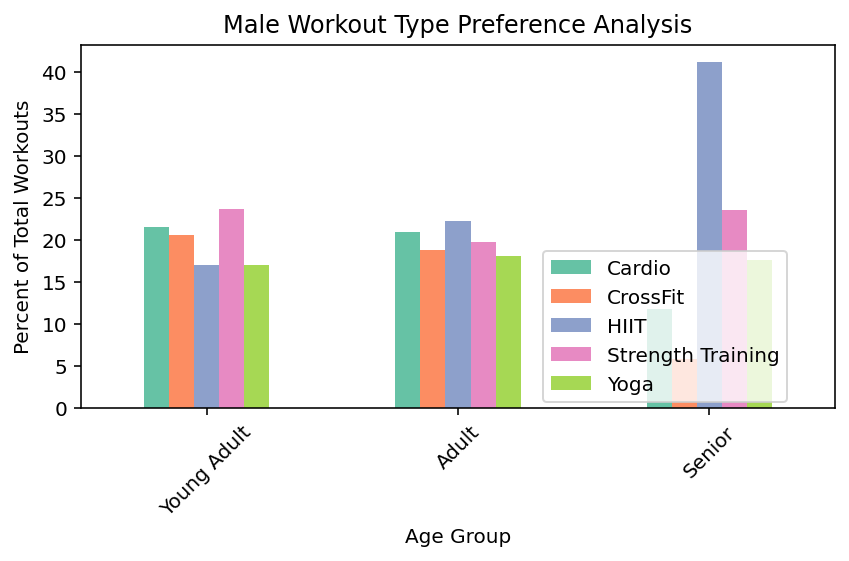

Above, we can see that adult and young adult males have a slightly similar preference for cardio. Each age group has specific preferences otherwise, with young adults unsurprisingly favoring strength training while adults most favoring HIIT. Seniors surprisingly favor HIIT. It is worth noting here that the number of seniors in the dataset is small (15 total) and all are the same age (65), so this is likely not an accurate representation of all seniors.

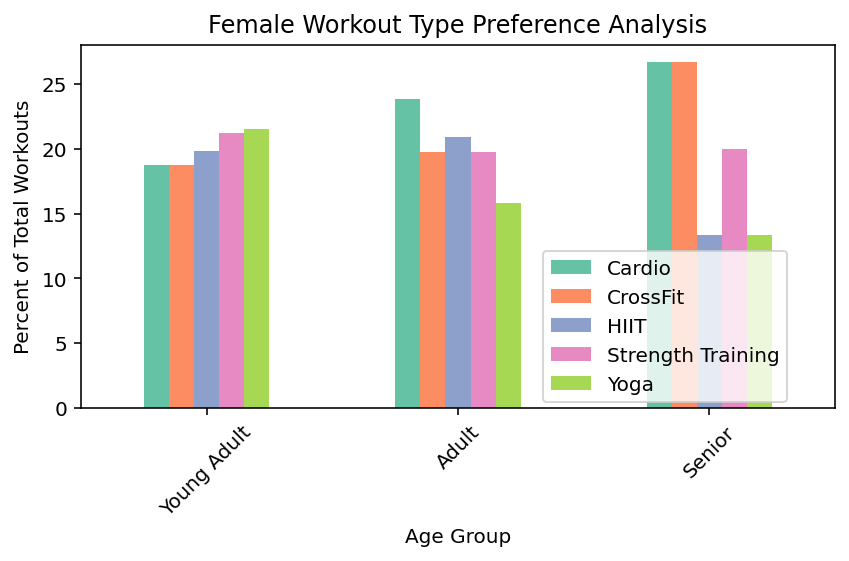

Here, we see senior and adult females prefer cardio, with young adults most performing yoga and strength training. Adult females seem to prefer yoga least, which I found surprising.

Next, we take a look at more density plots.

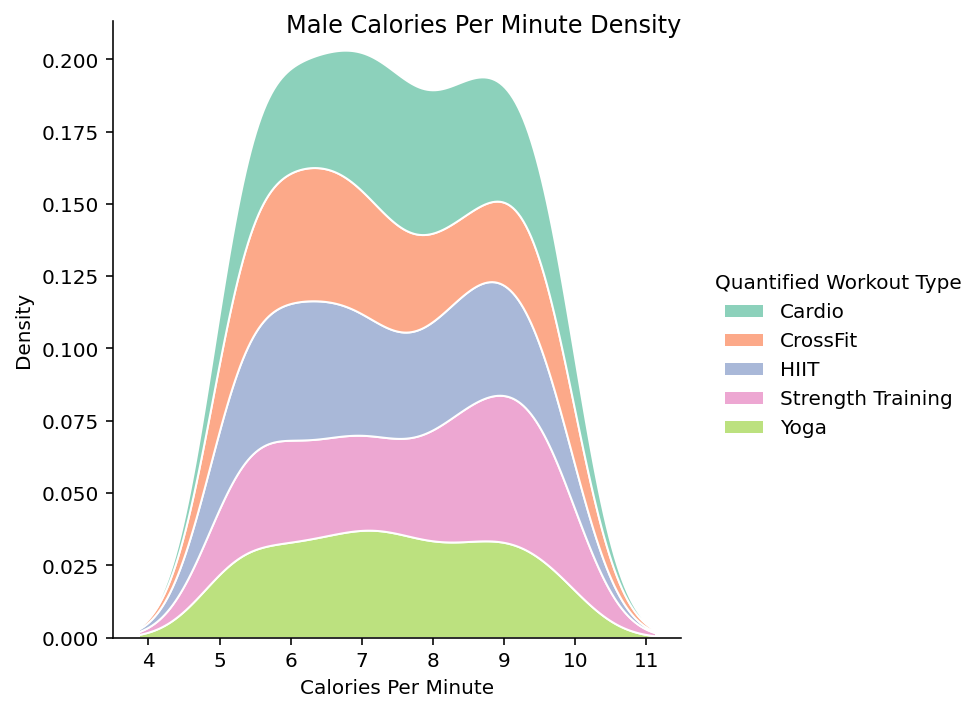

From this plot, we see notably consistent differences in Calories Per Minute (CPM) density from 5 to 10 CPM. The trough of roughly 7.5-8.5 CPM is possibly due to workouts typically being short and intense (the high peak near 9CPM), or longer but less taxing (easy cardio, strength training, etc).

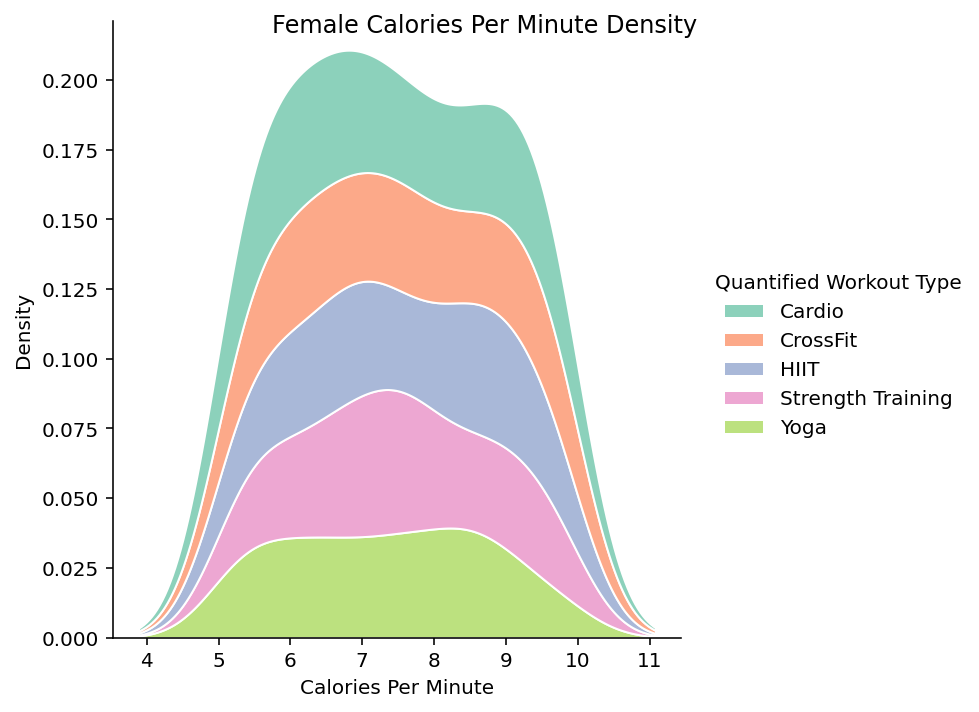

We see similarities and differences between males and females as we analyze the female plot. Notably, females training strength participate in markedly less intense sessions than males as the peak near 7 CPM illustrates. Further, it seems that females across all workout types participate in less high-intensity (or high CPM) workouts. However, the left peak in each distribution is markedly higher in CPM than the left peak for males. This means, while females may not train to high-intensity as males do, they push harder intensities in their longer duration workouts.

This concludes my course project, I hope it was informative and thank you for for your attention. Take care and have a great day!